# Model Experiment — SARIMA

## Section 1 — Install & Imports

In [1]:
!pip install pmdarima --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from pmdarima import auto_arima
from pmdarima.arima import ARIMA as PmdARIMA
from pmdarima.arima.utils import ndiffs, nsdiffs

from google.colab import drive
drive.mount('/content/drive')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.8 MB/s eta 0:00:00
Mounted at /content/drive


## Section 2 — Load Cleaned Data

In [2]:
path = '/content/drive/MyDrive/ML-final/data/processed/'
df = pd.read_csv(path + 'walmart_cleaned.csv')
df['Date'] = pd.to_datetime(df['Date'])

markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)  # SARIMAX exog can't take NaN either

print(df.shape)
df.head()


(421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
1,1,2,2010-02-05,50605.27,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
2,1,3,2010-02-05,13740.12,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
3,1,4,2010-02-05,39954.04,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106
4,1,5,2010-02-05,32229.38,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106


## Section 3 — Wandb Login

In [3]:
wandb.login()


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gormo22 (gormo22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Section 4 — Series Selection (`SARIMA_Series_Selection`)

Same stratified-sampling logic as `model_experiment_ARIMA.ipynb` (top 5 / mid 3 / low 2 by total
revenue, restricted to series with >=100 weeks of history), reused here deliberately so the two
notebooks are directly comparable on the *same* series -- otherwise a "SARIMA beat ARIMA" claim
in the README would be confounded by having evaluated on different data.

SARIMA is treated as its own separate architecture per the assignment's file-per-architecture
convention. This notebook adds the seasonal (P, D, Q, m) component on top of the plain ARIMA
already covered in `model_experiment_ARIMA.ipynb`, and drops the Fourier-term workaround used
there, since a proper seasonal component is exactly what those Fourier terms were standing in for.

In [4]:
run = wandb.init(project="walmart-sales-forecasting", group="SARIMA_Training",
                  name="SARIMA_Series_Selection", job_type="scoping")

series_totals = df.groupby(['Store', 'Dept'])['Weekly_Sales'].sum().sort_values(ascending=False)
series_lengths = df.groupby(['Store', 'Dept']).size()

# keep only reasonably complete series (>=100 weeks) so a full seasonal cycle (m=52) is even observable
valid_series = series_lengths[series_lengths >= 100].index
series_totals = series_totals[series_totals.index.isin(valid_series)]

top_series = series_totals.head(5).index.tolist()
mid_start = len(series_totals) // 2
mid_series = series_totals.iloc[mid_start:mid_start + 3].index.tolist()
low_series = series_totals.tail(2).index.tolist()

selected_series = top_series + mid_series + low_series
print("Selected (Store, Dept) series for SARIMA (same series as the ARIMA notebook):")
for s in selected_series:
    print(s, "-> total sales:", round(series_totals[s], 2))

wandb.config.update({
    "sampling_strategy": "stratified_top5_mid3_low2_by_total_revenue",
    "n_series_selected": len(selected_series),
    "selected_series": [str(s) for s in selected_series],
    "reused_from": "model_experiment_ARIMA.ipynb -- same series for fair comparison",
})
wandb.finish()


Selected (Store, Dept) series for SARIMA (same series as the ARIMA notebook):
(14, 92) -> total sales: 26101497.71
(2, 92) -> total sales: 23572153.03
(20, 92) -> total sales: 23542625.04
(13, 92) -> total sales: 23170876.2
(4, 92) -> total sales: 22789210.43
(28, 24) -> total sales: 1191029.24
(45, 22) -> total sales: 1190340.69
(3, 8) -> total sales: 1188366.35
(17, 45) -> total sales: 2235.88
(36, 25) -> total sales: 2210.11


## Section 5 — Series Preparation (reindex + gap filling)

In [5]:
def prep_series(data, store, dept):
    s = data[(data['Store'] == store) & (data['Dept'] == dept)].sort_values('Date')
    s = s.set_index('Date')
    full_idx = pd.date_range(s.index.min(), s.index.max(), freq='W-FRI')  # Walmart weeks
    s = s.reindex(full_idx)
    s.index.name = 'Date'

    # Weekly_Sales: interpolate small gaps -- documented choice, not silent
    s['Weekly_Sales'] = s['Weekly_Sales'].interpolate(limit_direction='both')
    # exogenous columns: forward/back fill (slow-moving or calendar-derivable)
    for col in ['IsHoliday', 'CPI', 'Unemployment', 'Fuel_Price'] + markdown_cols:
        if col in s.columns:
            s[col] = s[col].ffill().bfill()

    s['Store'] = store
    s['Dept'] = dept
    return s

prepared_series = {s: prep_series(df, s[0], s[1]) for s in selected_series}
for s, data in prepared_series.items():
    n_raw = df[(df['Store'] == s[0]) & (df['Dept'] == s[1])].shape[0]
    print(f"Store {s[0]} Dept {s[1]}: {n_raw} raw rows -> {len(data)} rows after reindex")


Store 14 Dept 92: 143 raw rows -> 143 rows after reindex
Store 2 Dept 92: 143 raw rows -> 143 rows after reindex
Store 20 Dept 92: 143 raw rows -> 143 rows after reindex
Store 13 Dept 92: 143 raw rows -> 143 rows after reindex
Store 4 Dept 92: 143 raw rows -> 143 rows after reindex
Store 28 Dept 24: 143 raw rows -> 143 rows after reindex
Store 45 Dept 22: 143 raw rows -> 143 rows after reindex
Store 3 Dept 8: 143 raw rows -> 143 rows after reindex
Store 17 Dept 45: 105 raw rows -> 142 rows after reindex
Store 36 Dept 25: 112 raw rows -> 140 rows after reindex


## Section 6 — Seasonal Differencing Diagnostics (`SARIMA_Seasonal_Diagnostics`)

Two questions to answer before fitting: how much regular differencing `d` does each series need
(same ADF/KPSS logic as the ARIMA notebook), and how much *seasonal* differencing `D` at m=52 it
needs. `D` is estimated with the Canova-Hansen (`ch`) seasonal-stationarity test via
`pmdarima.arima.utils.nsdiffs`, which is the seasonal counterpart of the ADF/KPSS pair used for `d`.

We compute `D` per series but also take the **majority-vote value across the sample** and fix it
for the `auto_arima` seasonal search in Section 9 -- letting `D` float freely per series inside
`auto_arima` with `m=52` on top of an already-expensive stepwise (p,q,P,Q) search is not tractable
for a 10-series notebook run in a reasonable time, and is a documented scoping decision (same spirit
as the ARIMA notebook fixing a stratified sample instead of fitting all ~3,000 series).

In [6]:
run = wandb.init(project="walmart-sales-forecasting", group="SARIMA_Training",
                  name="SARIMA_Seasonal_Diagnostics", job_type="diagnostics")

M = 52  # yearly seasonality on weekly data

def check_regular_d(series):
    adf_p = adfuller(series.dropna())[1]
    kpss_p = kpss(series.dropna(), regression='c', nlags='auto')[1]
    d = 1 if adf_p > 0.05 else 0
    return d, adf_p, kpss_p

seasonal_diag_results = []
for s, data in prepared_series.items():
    series = data['Weekly_Sales']
    d, adf_p, kpss_p = check_regular_d(series)
    D = nsdiffs(series, m=M, test='ch', max_D=1)

    seasonal_diag_results.append({
        "store": s[0], "dept": s[1], "adf_p": adf_p, "kpss_p": kpss_p,
        "suggested_d": d, "suggested_D": D,
    })
    print(f"Store {s[0]} Dept {s[1]}: d={d} (ADF p={adf_p:.4f}), D={D} (Canova-Hansen, m={M})")

seasonal_diag_df = pd.DataFrame(seasonal_diag_results)
fixed_D = int(seasonal_diag_df['suggested_D'].mode().iloc[0])
print(f"\nMajority-vote seasonal difference across sample: D={fixed_D} (fixed for Section 9 onward)")

wandb.log({"seasonal_diagnostics": wandb.Table(dataframe=seasonal_diag_df)})
wandb.config.update({"seasonal_period_m": M, "fixed_D": fixed_D,
                      "D_selection_method": "canova_hansen_majority_vote"})
wandb.finish()


Store 14 Dept 92: d=1 (ADF p=0.6770), D=1 (Canova-Hansen, m=52)
Store 2 Dept 92: d=1 (ADF p=0.0516), D=1 (Canova-Hansen, m=52)
Store 20 Dept 92: d=1 (ADF p=0.5214), D=1 (Canova-Hansen, m=52)
Store 13 Dept 92: d=1 (ADF p=0.6332), D=1 (Canova-Hansen, m=52)
Store 4 Dept 92: d=1 (ADF p=0.4991), D=1 (Canova-Hansen, m=52)
Store 28 Dept 24: d=0 (ADF p=0.0000), D=1 (Canova-Hansen, m=52)
Store 45 Dept 22: d=1 (ADF p=0.1177), D=1 (Canova-Hansen, m=52)
Store 3 Dept 8: d=1 (ADF p=0.0570), D=1 (Canova-Hansen, m=52)
Store 17 Dept 45: d=0 (ADF p=0.0385), D=1 (Canova-Hansen, m=52)


/tmp/ipykernel_1455/3245419382.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(series.dropna(), regression='c', nlags='auto')[1]
/tmp/ipykernel_1455/3245419382.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(series.dropna(), regression='c', nlags='auto')[1]
/tmp/ipykernel_1455/3245419382.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_p = kpss(series.dropna(), regression='c', nlags='auto')[1]
/tmp/ipykernel_1455/3245419382.py:8: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-val

Store 36 Dept 25: d=0 (ADF p=0.0001), D=1 (Canova-Hansen, m=52)

Majority-vote seasonal difference across sample: D=1 (fixed for Section 9 onward)


## Section 7 — Exogenous Feature Engineering (`SARIMA_Exogenous_Features`)

Unlike the ARIMA notebook, the Fourier sin/cos terms are **dropped** here: they were a workaround
for ARIMA's lack of a native seasonal component, and keeping both would let the seasonal (P, D, Q,
m) term and the Fourier terms fight over the same yearly cycle, muddying interpretation and
inflating standard errors from collinearity. Holiday dummies, macro regressors, and markdown flags
are kept, since those aren't redundant with a seasonal AR/MA structure -- they encode information
the seasonal component can't (e.g. the exact date Labor Day falls on each specific year, not just
"52 weeks ago").

In [7]:
super_bowl    = pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'])
labor_day     = pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'])
thanksgiving  = pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'])
christmas     = pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'])

run = wandb.init(project="walmart-sales-forecasting", group="SARIMA_Training",
                  name="SARIMA_Exogenous_Features", job_type="feature-engineering")

def build_exog(data):
    idx = data.index
    exog = pd.DataFrame(index=idx)
    exog['IsHoliday']        = data['IsHoliday'].astype(int).values
    exog['Is_SuperBowl']     = idx.isin(super_bowl).astype(int)
    exog['Is_LaborDay']      = idx.isin(labor_day).astype(int)
    exog['Is_Thanksgiving']  = idx.isin(thanksgiving).astype(int)
    exog['Is_Christmas']     = idx.isin(christmas).astype(int)
    exog['CPI']              = data['CPI'].values
    exog['Unemployment']     = data['Unemployment'].values
    exog['Fuel_Price']       = data['Fuel_Price'].values
    exog['Total_Markdown']   = data[markdown_cols].sum(axis=1).values
    exog['Has_Markdown']     = (exog['Total_Markdown'] > 0).astype(int)
    return exog

def standardize_exog_fold(train_exog, val_exog, cols=('CPI', 'Unemployment', 'Fuel_Price', 'Total_Markdown')):
    """Leakage-safe standardization: fit mu/sigma on the TRAIN portion only, apply to both.
    Same pattern used in the ARIMA and XGBoost notebooks -- one shared routine, called fresh for
    every split, instead of standardizing over train+val combined before any split exists."""
    train_exog = train_exog.copy()
    val_exog = val_exog.copy()
    for col in cols:
        mu, sigma = train_exog[col].mean(), train_exog[col].std()
        sigma = sigma if sigma > 0 else 1
        train_exog[col] = (train_exog[col] - mu) / sigma
        val_exog[col] = (val_exog[col] - mu) / sigma
    return train_exog, val_exog

exog_by_series = {s: build_exog(data) for s, data in prepared_series.items()}
print("Exogenous feature matrix columns:", list(exog_by_series[selected_series[0]].columns))
print(exog_by_series[selected_series[0]].head())

wandb.config.update({
    "exog_features": list(exog_by_series[selected_series[0]].columns),
    "excluded_features_reason": "Fourier sin/cos terms dropped (redundant with seasonal P/D/Q/m); "
                                 "Sales_Lag*, RollMean/RollStd, Dept_Avg_Sales, Store_Avg_Sales, "
                                 "Partner_Dept omitted -- redundant with SARIMA's own AR/MA structure",
})
wandb.finish()


Exogenous feature matrix columns: ['IsHoliday', 'Is_SuperBowl', 'Is_LaborDay', 'Is_Thanksgiving', 'Is_Christmas', 'CPI', 'Unemployment', 'Fuel_Price', 'Total_Markdown', 'Has_Markdown']
            IsHoliday  Is_SuperBowl  Is_LaborDay  Is_Thanksgiving  \
Date                                                                
2010-02-05          0             0            0                0   
2010-02-12          1             1            0                0   
2010-02-19          0             0            0                0   
2010-02-26          0             0            0                0   
2010-03-05          0             0            0                0   

            Is_Christmas         CPI  Unemployment  Fuel_Price  \
Date                                                             
2010-02-05             0  181.871190         8.992       2.784   
2010-02-12             0  181.982317         8.992       2.773   
2010-02-19             0  182.034782         8.992       2.745   
2

## Section 8 — Train/Validation Split (`SARIMA_Train_Val_Split`)

In [8]:
run = wandb.init(project="walmart-sales-forecasting", group="SARIMA_Training",
                  name="SARIMA_Train_Val_Split", job_type="split")

cutoff_date = df['Date'].quantile(0.9, interpolation='nearest')  # same cutoff as ARIMA/XGBoost tracks
print("Cutoff date (matches ARIMA/XGBoost tracks):", cutoff_date)

train_val_split = {}
for s in selected_series:
    data = prepared_series[s]
    exog = exog_by_series[s]
    train_mask = data.index <= cutoff_date
    val_mask = data.index > cutoff_date
    train_exog, val_exog = standardize_exog_fold(exog[train_mask], exog[val_mask])
    train_val_split[s] = {
        "train_series": data['Weekly_Sales'][train_mask],
        "val_series":   data['Weekly_Sales'][val_mask],
        "train_exog":   train_exog,
        "val_exog":     val_exog,
    }
    print(f"Store {s[0]} Dept {s[1]}: train={train_mask.sum()}, val={val_mask.sum()}")

wandb.config.update({"cutoff_date": str(cutoff_date), "split_strategy": "same_cutoff_as_arima_and_xgboost_time_based"})
wandb.finish()


Cutoff date (matches ARIMA/XGBoost tracks): 2012-07-20 00:00:00
Store 14 Dept 92: train=129, val=14
Store 2 Dept 92: train=129, val=14
Store 20 Dept 92: train=129, val=14
Store 13 Dept 92: train=129, val=14
Store 4 Dept 92: train=129, val=14
Store 28 Dept 24: train=129, val=14
Store 45 Dept 22: train=129, val=14
Store 3 Dept 8: train=129, val=14
Store 17 Dept 45: train=128, val=14
Store 36 Dept 25: train=126, val=14


## Section 9 — Seasonal Order Selection + Training (`SARIMA_Training`)

`auto_arima` with `seasonal=True, m=52` and `D` fixed from Section 6. The (P, Q) seasonal search
space is kept deliberately narrow (`max_P=1, max_Q=1`) -- with m=52 every seasonal AR/MA term costs
52 lags of extra state, so a wide seasonal grid combined with a wide (p, q) grid is not affordable
for a 10-series notebook. The non-seasonal (p, q) side keeps the same range as the ARIMA notebook
for comparability.

In [9]:
run = wandb.init(project="walmart-sales-forecasting", group="SARIMA_Training",
                  name="SARIMA_Training", job_type="training")

def weighted_mae(y_true, y_pred, weights):
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

trained_models = {}
training_results = []

for s in selected_series:
    split = train_val_split[s]
    train_s, val_s = split["train_series"], split["val_series"]
    train_exog, val_exog = split["train_exog"], split["val_exog"]

    if len(val_s) == 0 or len(train_s) < 2 * M:
        print(f"Skipping Store {s[0]} Dept {s[1]}: insufficient data for a full seasonal cycle x2")
        continue

    model = auto_arima(train_s, exogenous=train_exog,
                        seasonal=True, m=M, D=fixed_D,
                        start_p=0, max_p=3, start_q=0, max_q=3, d=None,
                        start_P=0, max_P=1, start_Q=0, max_Q=1,
                        stepwise=True, information_criterion='aic', suppress_warnings=True)
    preds = model.predict(n_periods=len(val_s), exogenous=val_exog)

    weights = np.where(val_exog['IsHoliday'].values == 1, 5, 1)
    wmae = weighted_mae(val_s.values, preds, weights)

    # seasonal-naive baseline: same week last year, falling back to last observed value
    naive_preds = train_s.reindex(val_s.index - pd.Timedelta(weeks=52))
    naive_preds.index = val_s.index
    naive_preds = naive_preds.fillna(train_s.iloc[-1])
    naive_wmae = weighted_mae(val_s.values, naive_preds.values, weights)

    trained_models[s] = model
    training_results.append({
        "store": s[0], "dept": s[1], "order": str(model.order), "seasonal_order": str(model.seasonal_order),
        "aic": model.aic(), "val_wmae": wmae, "naive_wmae": naive_wmae,
        "beats_naive": bool(wmae < naive_wmae)
    })
    print(f"Store {s[0]} Dept {s[1]}: order={model.order}, seasonal_order={model.seasonal_order}, "
          f"val_wmae={wmae:.2f}, naive_wmae={naive_wmae:.2f}, beats_naive={wmae < naive_wmae}")

training_results_df = pd.DataFrame(training_results)
wandb.log({"training_results": wandb.Table(dataframe=training_results_df)})
wandb.finish()
print(training_results_df)


Store 14 Dept 92: order=(1, 0, 0), seasonal_order=(0, 1, 0, 52), val_wmae=28296.25, naive_wmae=30758.60, beats_naive=True
Store 2 Dept 92: order=(1, 1, 0), seasonal_order=(0, 1, 0, 52), val_wmae=3275.76, naive_wmae=15884.55, beats_naive=True
Store 20 Dept 92: order=(1, 1, 0), seasonal_order=(0, 1, 0, 52), val_wmae=12906.53, naive_wmae=7284.84, beats_naive=False
Store 13 Dept 92: order=(2, 1, 1), seasonal_order=(0, 1, 1, 52), val_wmae=10702.09, naive_wmae=14293.30, beats_naive=True
Store 4 Dept 92: order=(1, 1, 0), seasonal_order=(0, 1, 1, 52), val_wmae=6028.67, naive_wmae=9916.75, beats_naive=True
Store 28 Dept 24: order=(3, 1, 3), seasonal_order=(1, 1, 0, 52), val_wmae=1766.57, naive_wmae=1792.44, beats_naive=True
Store 45 Dept 22: order=(0, 0, 1), seasonal_order=(0, 1, 1, 52), val_wmae=647.07, naive_wmae=697.71, beats_naive=True
Store 3 Dept 8: order=(0, 1, 1), seasonal_order=(1, 1, 0, 52), val_wmae=508.89, naive_wmae=810.67, beats_naive=True
Store 17 Dept 45: order=(1, 0, 0), season

   store  dept      order seasonal_order          aic      val_wmae  \
0     14    92  (1, 0, 0)  (0, 1, 0, 52)  1733.024255  28296.246159   
1      2    92  (1, 1, 0)  (0, 1, 0, 52)  1622.038889   3275.760158   
2     20    92  (1, 1, 0)  (0, 1, 0, 52)  1678.996075  12906.526842   
3     13    92  (2, 1, 1)  (0, 1, 1, 52)  1590.949620  10702.085183   
4      4    92  (1, 1, 0)  (0, 1, 1, 52)  1602.551054   6028.672370   
5     28    24  (3, 1, 3)  (1, 1, 0, 52)  1275.883874   1766.574953   
6     45    22  (0, 0, 1)  (0, 1, 1, 52)  1343.867104    647.067865   
7      3     8  (0, 1, 1)  (1, 1, 0, 52)  1198.163111    508.892371   
8     17    45  (1, 0, 0)  (0, 1, 1, 52)   694.492382     12.592150   
9     36    25  (0, 1, 0)  (0, 1, 0, 52)   641.491826     16.109286   

     naive_wmae  beats_naive  
0  30758.602222         True  
1  15884.547778         True  
2   7284.837778        False  
3  14293.302778         True  
4   9916.752778         True  
5   1792.443889         True  
6

## Section 10 — Residual Diagnostics (`SARIMA_Diagnostics`)

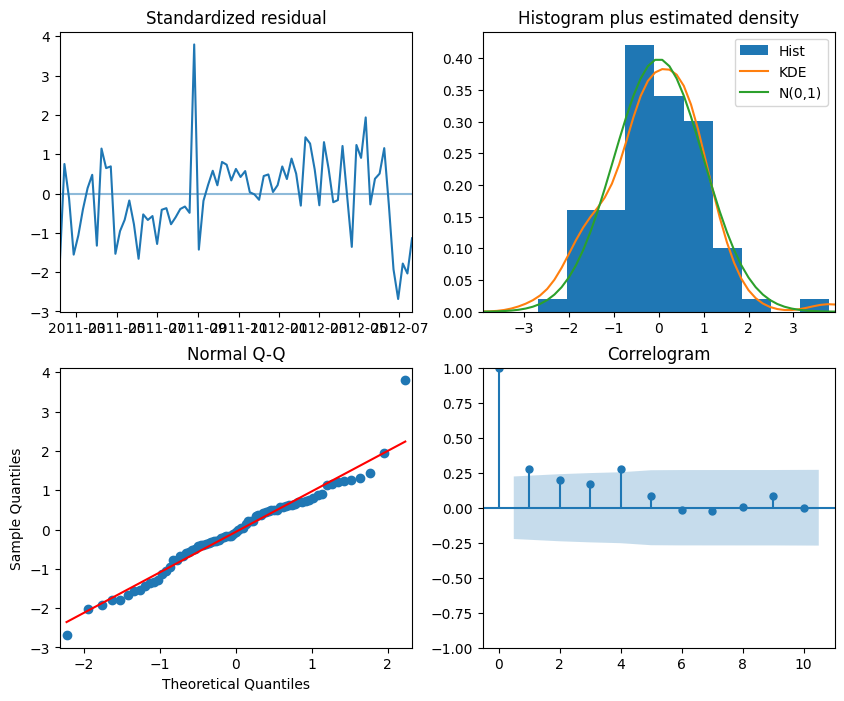

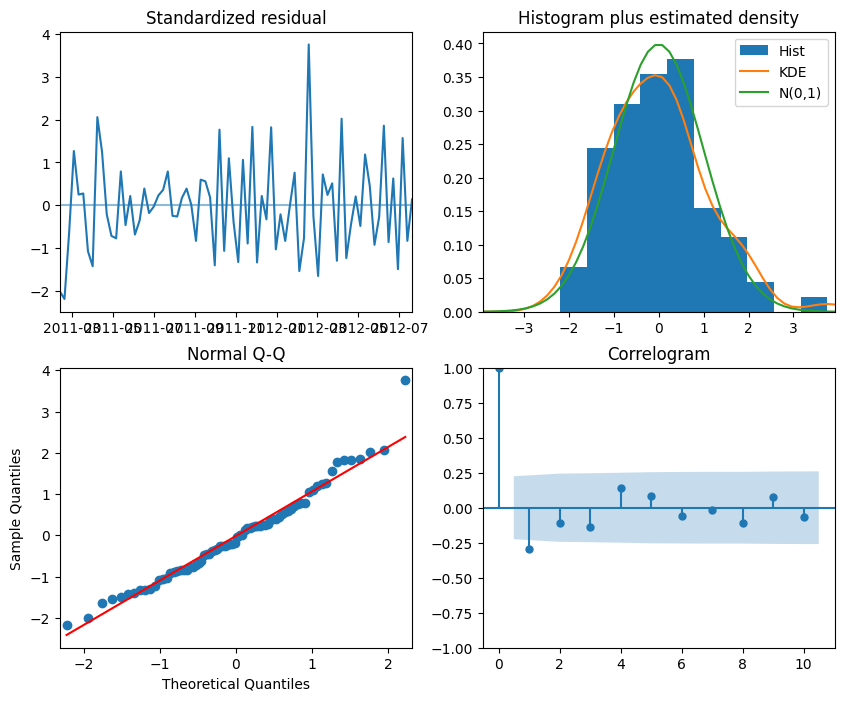

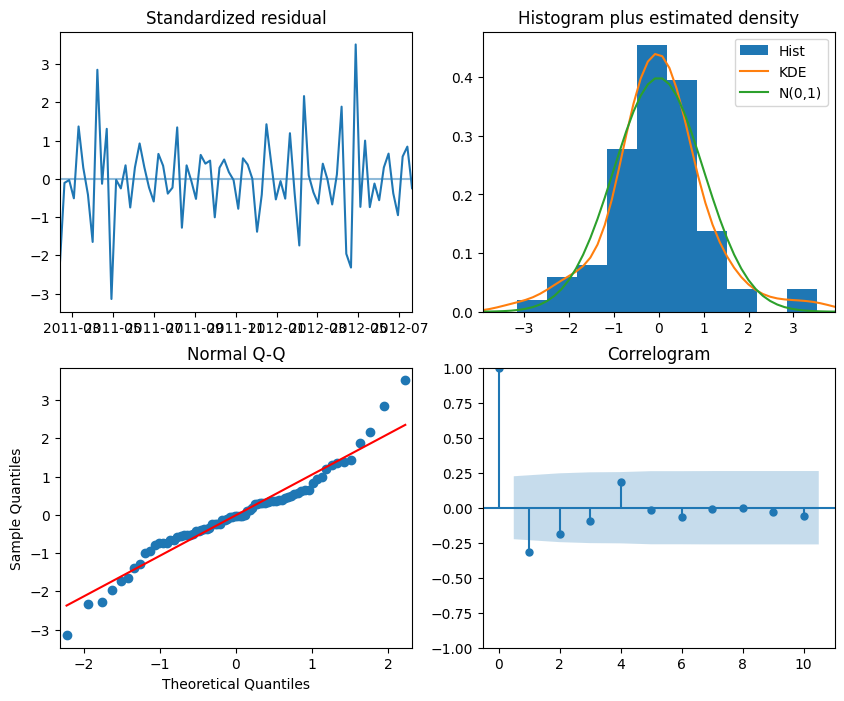

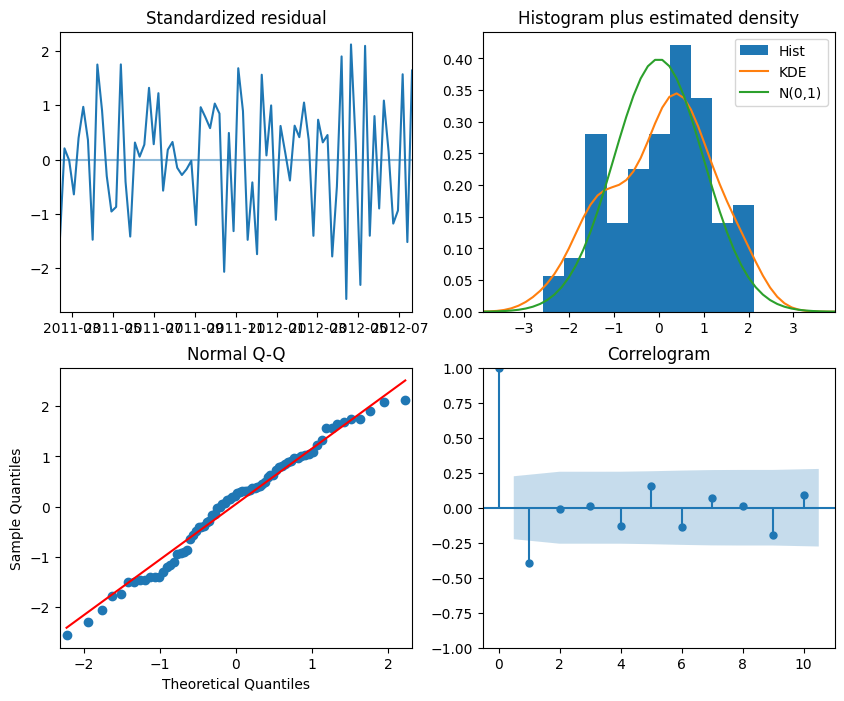

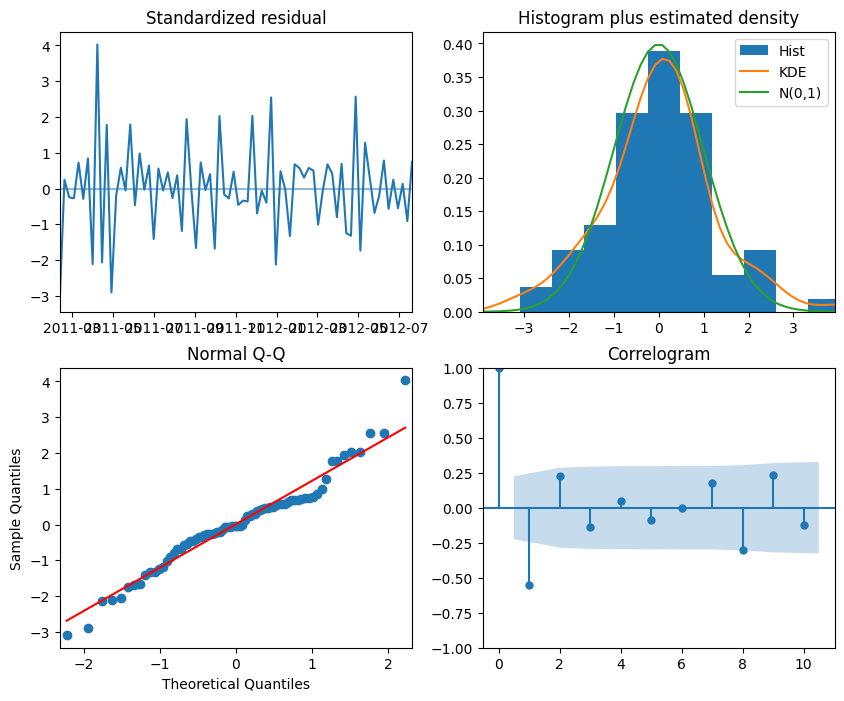

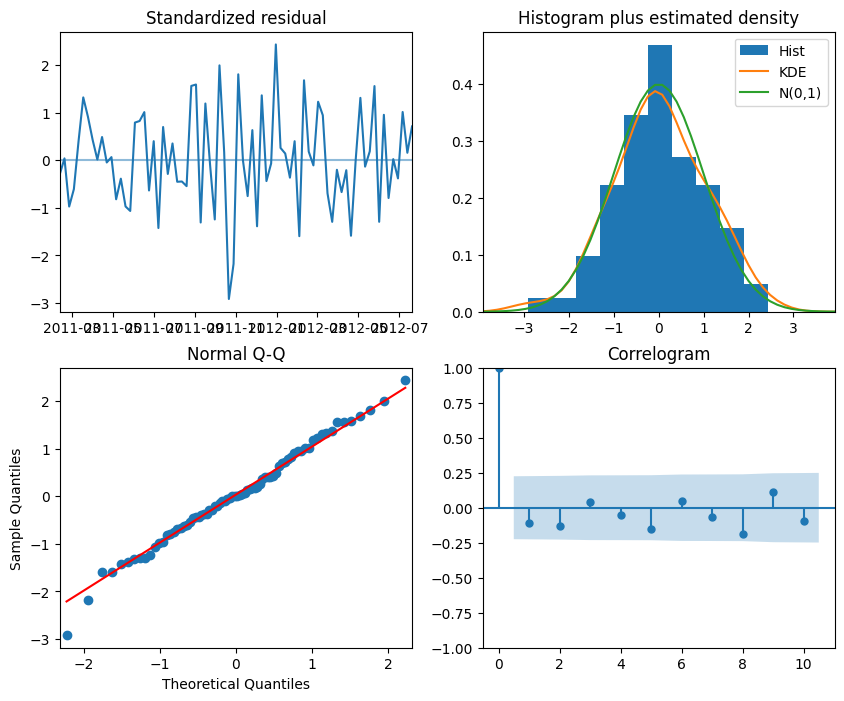

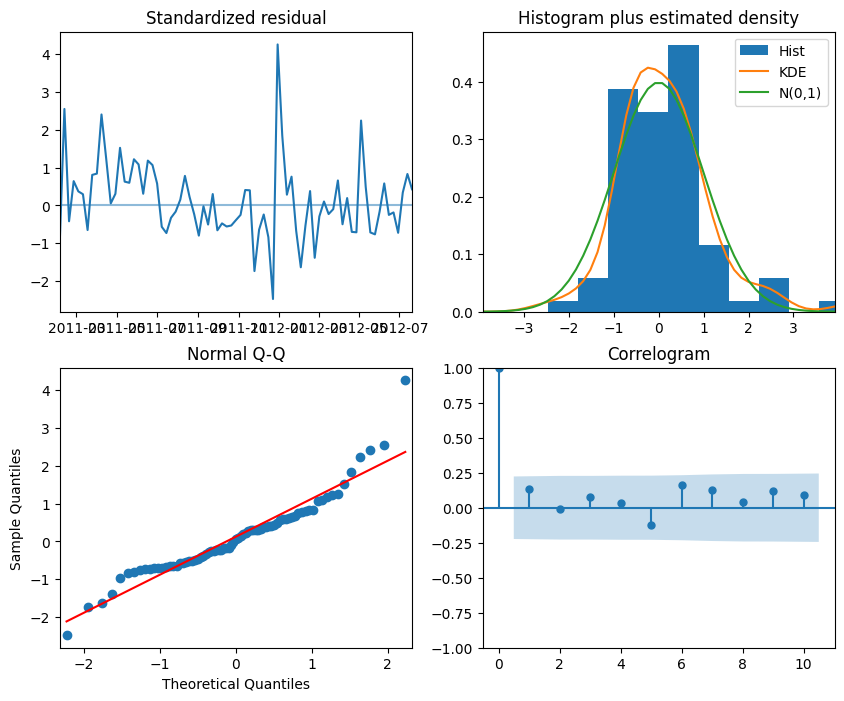

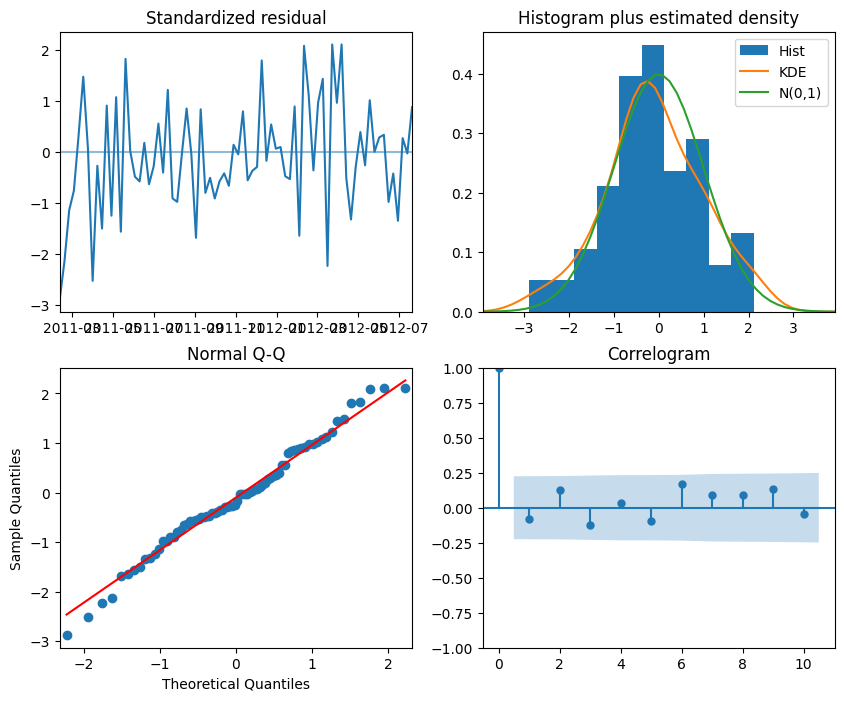

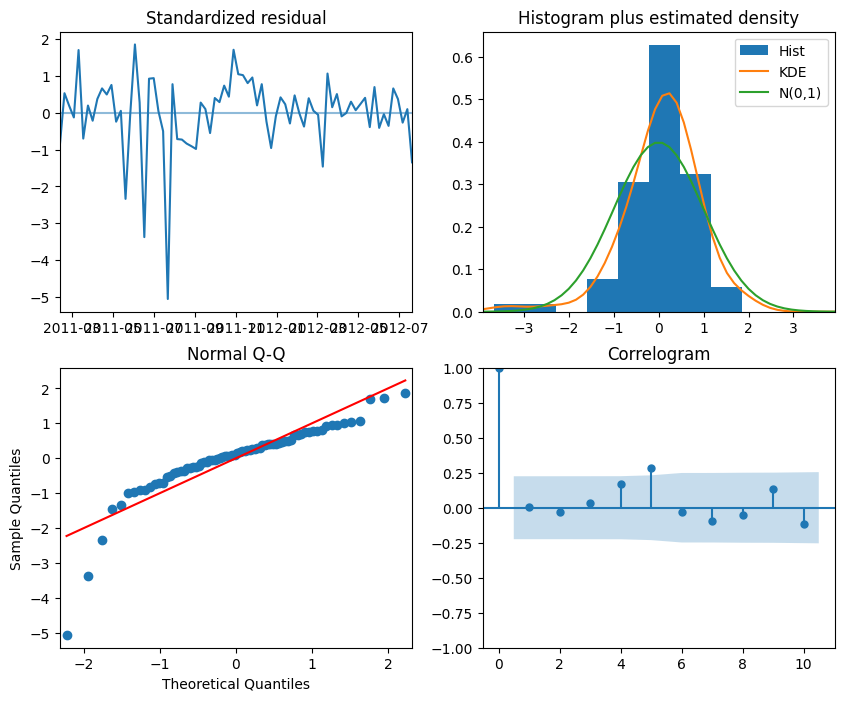

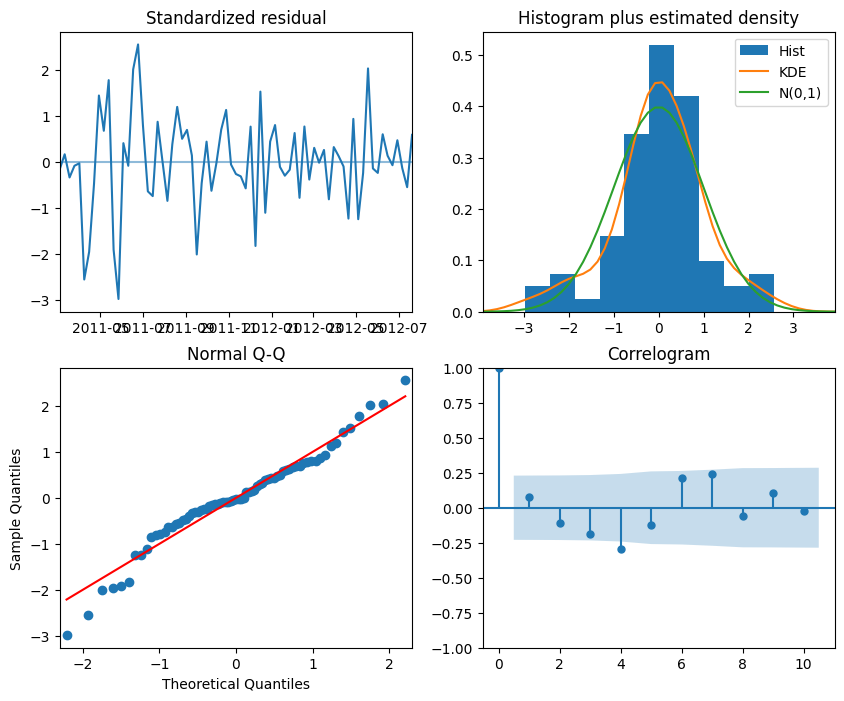

   store  dept  ljungbox_p_lag10  ljungbox_p_lag20  residuals_look_white_noise
0     14    92     1.447151e-199     2.407466e-299                       False
1      2    92      5.069083e-01      9.484421e-01                        True
2     20    92      1.382619e-01      1.696768e-01                        True
3     13    92      6.882688e-01      9.387252e-01                        True
4      4    92      4.552419e-01      7.198579e-01                        True
5     28    24      1.515027e-01      1.197471e-01                        True
6     45    22     1.086947e-132     8.276499e-188                       False
7      3     8      8.973085e-01      9.875026e-01                        True
8     17    45      1.136975e-26      1.134989e-32                       False
9     36    25      4.617005e-04      4.395194e-03                       False


In [10]:
run = wandb.init(project="walmart-sales-forecasting", group="SARIMA_Training",
                  name="SARIMA_Diagnostics", job_type="diagnostics")

diag_results = []
for s, model in trained_models.items():
    resid = model.resid()
    lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
    diag_results.append({
        "store": s[0], "dept": s[1],
        "ljungbox_p_lag10": lb['lb_pvalue'].iloc[0],
        "ljungbox_p_lag20": lb['lb_pvalue'].iloc[1],
        "residuals_look_white_noise": bool(lb['lb_pvalue'].iloc[0] > 0.05 and lb['lb_pvalue'].iloc[1] > 0.05),
    })

    fig = model.plot_diagnostics(figsize=(10, 8))
    wandb.log({f"diagnostics_store{s[0]}_dept{s[1]}": wandb.Image(fig)})
    plt.show()
    plt.close()

diag_df = pd.DataFrame(diag_results)
print(diag_df)
wandb.log({"diagnostics_table": wandb.Table(dataframe=diag_df)})
wandb.finish()


## Section 11 — Evaluation Summary (`SARIMA_Evaluation`)

{'mean_val_wmae': np.float64(6416.0527336312225), 'mean_naive_wmae': np.float64(8145.515706349205), 'pct_series_beating_naive': np.float64(70.0), 'n_series_evaluated': 10}


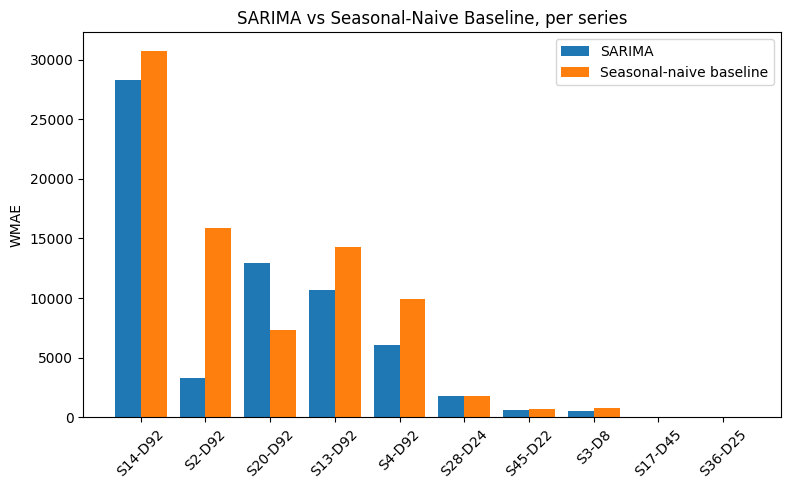

mean_naive_wmae,▁
mean_val_wmae,▁
n_series_evaluated,▁
pct_series_beating_naive,▁
mean_naive_wmae,8145.51571
mean_val_wmae,6416.05273
n_series_evaluated,10
pct_series_beating_naive,70


SARIMA_Evaluation run finished


In [11]:
run = wandb.init(project="walmart-sales-forecasting", group="SARIMA_Training",
                  name="SARIMA_Evaluation", job_type="evaluation")

summary = {
    "mean_val_wmae": training_results_df['val_wmae'].mean(),
    "mean_naive_wmae": training_results_df['naive_wmae'].mean(),
    "pct_series_beating_naive": training_results_df['beats_naive'].mean() * 100,
    "n_series_evaluated": len(training_results_df),
}
print(summary)
wandb.log(summary)

plt.figure(figsize=(9, 5))
x = np.arange(len(training_results_df))
plt.bar(x - 0.2, training_results_df['val_wmae'], width=0.4, label='SARIMA')
plt.bar(x + 0.2, training_results_df['naive_wmae'], width=0.4, label='Seasonal-naive baseline')
plt.xticks(x, [f"S{r.store}-D{r.dept}" for r in training_results_df.itertuples()], rotation=45)
plt.ylabel("WMAE"); plt.legend()
plt.title("SARIMA vs Seasonal-Naive Baseline, per series")
wandb.log({"SARIMA_vs_Naive_Plot": wandb.Image(plt)})
plt.show()
plt.close()

wandb.finish()
print("SARIMA_Evaluation run finished")


## Section 12 — Random-Sample Pooled Validation (`SARIMA_Pooled_Random_Sample_Validation`)

Same purpose as the ARIMA notebook's pooled-validation section: complements the small curated
stratified sample (Sections 4-11) with a large **random** sample evaluated with a single **pooled**
WMAE across all predictions, matching how Kaggle's leaderboard metric is actually computed.

The random sample size here (60) is smaller than the ARIMA notebook's (180) -- fitting a seasonal
model with m=52 per series is meaningfully more expensive than plain ARIMA, and running 180 of them
with a fixed order is not a good time trade-off for what this section is checking (aggregate
robustness, not per-series optimality). This is a documented scoping decision, not an inconsistency.
The seasonal order is fixed (not re-searched per series) for the same reason `FIXED_ORDER` was used
in the ARIMA notebook's equivalent section.

In [12]:
RANDOM_SAMPLE_SIZE = 60
FIXED_ORDER = (1, 1, 1)
FIXED_SEASONAL_ORDER = (1, fixed_D, 1, M)  # (P, D, Q, m) -- fixed, not auto_arima, for the same
                                            # runtime reason FIXED_ORDER is fixed in the ARIMA notebook

run = wandb.init(project="walmart-sales-forecasting", group="SARIMA_Training",
                  name="SARIMA_Pooled_Random_Sample_Validation", job_type="evaluation")

all_valid_series = list(series_lengths[series_lengths >= 100].index)
sampled_series = list(pd.Series(all_valid_series).sample(
    n=min(RANDOM_SAMPLE_SIZE, len(all_valid_series)), random_state=42))

pooled_actual, pooled_pred, pooled_weight = [], [], []
n_success, n_failed = 0, 0

for store, dept in sampled_series:
    try:
        data = prep_series(df, store, dept)
        exog = build_exog(data)

        train_mask = data.index <= cutoff_date
        val_mask   = data.index > cutoff_date
        train_s, val_s = data['Weekly_Sales'][train_mask], data['Weekly_Sales'][val_mask]
        train_exog, val_exog = standardize_exog_fold(exog[train_mask], exog[val_mask])

        if len(val_s) == 0 or len(train_s) < 2 * M:
            n_failed += 1
            continue

        model = PmdARIMA(order=FIXED_ORDER, seasonal_order=FIXED_SEASONAL_ORDER, suppress_warnings=True)
        model.fit(train_s, exogenous=train_exog)
        preds = model.predict(n_periods=len(val_s), exogenous=val_exog)

        weights = np.where(val_exog['IsHoliday'].values == 1, 5, 1)
        pooled_actual.extend(val_s.values)
        pooled_pred.extend(np.asarray(preds))
        pooled_weight.extend(weights)
        n_success += 1

    except Exception:
        n_failed += 1
        continue

pooled_actual = np.array(pooled_actual)
pooled_pred   = np.array(pooled_pred)
pooled_weight = np.array(pooled_weight)
pooled_wmae = weighted_mae(pooled_actual, pooled_pred, pooled_weight)

print(f"Random sample: {len(sampled_series)} series attempted, {n_success} succeeded, "
      f"{n_failed} failed ({n_success/len(sampled_series)*100:.1f}% success rate)")
print(f"Total pooled predictions: {len(pooled_actual)}")
print(f"Pooled WMAE (Kaggle-consistent): {pooled_wmae:.2f}")
print(f"For comparison, mean-of-per-series WMAE from the stratified sample: {summary['mean_val_wmae']:.2f}")

wandb.log({
    "random_sample_size": len(sampled_series),
    "random_sample_success": n_success,
    "random_sample_failed": n_failed,
    "random_sample_success_rate": n_success / len(sampled_series) * 100,
    "pooled_wmae": pooled_wmae,
    "total_pooled_predictions": len(pooled_actual),
})

wandb.finish()
print("SARIMA_Pooled_Random_Sample_Validation run finished")


Random sample: 60 series attempted, 60 succeeded, 0 failed (100.0% success rate)
Total pooled predictions: 840
Pooled WMAE (Kaggle-consistent): 2175.62
For comparison, mean-of-per-series WMAE from the stratified sample: 6416.05


pooled_wmae,▁
random_sample_failed,▁
random_sample_size,▁
random_sample_success,▁
random_sample_success_rate,▁
total_pooled_predictions,▁
pooled_wmae,2175.61564
random_sample_failed,0
random_sample_size,60
random_sample_success,60
random_sample_success_rate,100


SARIMA_Pooled_Random_Sample_Validation run finished


## Section 13 — Save Per-Series Pipeline (`SARIMA_Save_Models`)

Same wrapper pattern as the ARIMA notebook: one fitted SARIMA model per sampled (Store, Dept)
series, packaged so `predict()` takes RAW future rows (test.csv + features.csv merged, unprocessed)
and reconstructs the exogenous matrix internally. Only covers the sampled series trained above,
same documented scoping limitation as the ARIMA notebook.

In [13]:
import pickle

run = wandb.init(project="walmart-sales-forecasting", group="SARIMA_Training",
                  name="SARIMA_Save_Models", job_type="pipeline-export")

class SARIMASeriesPipeline:
    """
    Holds one fitted SARIMA model per (Store, Dept) series, plus each series' own historical
    data needed to reproduce the exact exogenous feature matrix (holiday flags, macro
    standardization stats) it was trained on. predict() takes RAW future rows (matching
    test.csv + features.csv merged, unprocessed) -- the caller doesn't need to know about
    holiday-date tables at all. Unlike the ARIMA pipeline, no Fourier terms are reconstructed
    here since seasonality is handled by the model's own (P, D, Q, m) component.
    NOTE: only covers the stratified sample of series trained in this notebook.
    """
    def __init__(self, models_by_series, prepared_series, markdown_cols):
        self.models_by_series = models_by_series
        self.prepared_series = prepared_series
        self.markdown_cols = markdown_cols
        self.super_bowl    = pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10', '2013-02-08'])
        self.labor_day     = pd.to_datetime(['2010-09-10', '2011-09-09', '2012-09-07', '2013-09-06'])
        self.thanksgiving  = pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23', '2013-11-29'])
        self.christmas     = pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28', '2013-12-27'])

    def _build_exog(self, store, dept, raw_future_df):
        ref_data = self.prepared_series[(store, dept)]
        idx = pd.to_datetime(raw_future_df['Date'])

        exog = pd.DataFrame(index=idx)
        exog['IsHoliday']       = raw_future_df['IsHoliday'].astype(int).values
        exog['Is_SuperBowl']    = idx.isin(self.super_bowl).astype(int)
        exog['Is_LaborDay']     = idx.isin(self.labor_day).astype(int)
        exog['Is_Thanksgiving'] = idx.isin(self.thanksgiving).astype(int)
        exog['Is_Christmas']    = idx.isin(self.christmas).astype(int)
        exog['CPI']             = raw_future_df['CPI'].values
        exog['Unemployment']    = raw_future_df['Unemployment'].values
        exog['Fuel_Price']      = raw_future_df['Fuel_Price'].values
        exog['Total_Markdown']  = raw_future_df[self.markdown_cols].fillna(0).sum(axis=1).values
        exog['Has_Markdown']    = (exog['Total_Markdown'] > 0).astype(int)

        for col in ['CPI', 'Unemployment', 'Fuel_Price', 'Total_Markdown']:
            ref_col = ref_data[col] if col != 'Total_Markdown' else ref_data[self.markdown_cols].fillna(0).sum(axis=1)
            mu, sigma = ref_col.mean(), ref_col.std()
            exog[col] = (exog[col] - mu) / (sigma if sigma > 0 else 1)
        return exog

    def predict(self, store, dept, raw_future_df):
        key = (store, dept)
        if key not in self.models_by_series:
            raise ValueError(
                f"No trained SARIMA model for Store {store}, Dept {dept} -- "
                f"only the sampled series from Section 4 are covered."
            )
        exog = self._build_exog(store, dept, raw_future_df)
        return self.models_by_series[key].predict(n_periods=len(raw_future_df), exogenous=exog)

sarima_pipeline = SARIMASeriesPipeline(trained_models, prepared_series, markdown_cols)

with open("/content/sarima_pipeline.pkl", "wb") as f:
    pickle.dump(sarima_pipeline, f)

artifact = wandb.Artifact(
    name="sarima_series_pipeline", type="model",
    description=f"Per-series SARIMA (m=52) models for {len(trained_models)} sampled Store-Dept series. "
                f"mean_val_wmae={summary['mean_val_wmae']:.2f} (10-series stratified average), "
                f"pooled_wmae={pooled_wmae:.2f} (60-series random sample, Kaggle-consistent)"
)
artifact.add_file("/content/sarima_pipeline.pkl")
wandb.run.log_artifact(artifact)
wandb.finish()
print("SARIMA pipeline saved")


SARIMA pipeline saved
